# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: cinemática en el espacio-tiempo

In [1]:
!pip3 install -Uq numpy scipy einsteinpy matplotlib

In [2]:
import numpy as np

Vamos a escribir un solucionador de la ecuación de movimiento:

$$
\frac{d^2 \tilde{x}_L}{d\tau^2} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

Equivale:
$$
\frac{d\tilde{x}_L}{d\tau} = \tilde{U}\\
\frac{d\tilde{U}_L}{d\tau} = \tilde{A}_L(\tilde{x}_L,\tau)
$$

In [3]:
def edm_espacio_tiempo(tau, Ys, alpha):
    # Ys: contiene todas las variables del problema
    #  t, x, y, z, Ut, Ux, Uy, Uz
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    # Ecuaciones de movimiento
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    # ¿Cuánto valen las componentes de A?
    # La aceleración propia
    Apropia = np.array([0, alpha, 0, 0])

    # La aceleración en el sistema de coordenadas del observador
    gamma = Ut
    beta = Ux / gamma
    Lambda = np.array([
        [gamma, gamma*beta, 0, 0],
        [gamma*beta, gamma, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    Atierra = Lambda @ Apropia 
    # Así es

    dUt_dtau = Atierra[0]
    dUx_dtau = Atierra[1]
    dUy_dtau = Atierra[2]
    dUz_dtau = Atierra[3]

    return dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau

## Condiciones iniciales

Unidades relativistas:

In [19]:
c_SI = 299792458 # m/s
c = 1 # unidades relativistas
UT = 365.25 * 86400 # segundos en un año
# c = 1, c = UL / UT (similar G = UL^3 / (UM * UT^2))
UL = c_SI * UT
UV = UL / UT
UA = UL / UT**2

UL, UT, UV, UA

(9460730472580800.0, 31557600.0, 299792458.0, 9.499849735087587)

Condiciones iniciales expresadas en coordenadas espaciales y temporales:

In [20]:
t = 0
x = 0
y = 0
z = 0

vx = 0 
vy = 0
vz = 0

Condiciones iniciales expresadas como cuadrivectores:

In [21]:
T = c*t
# x, y, z: son las mismas
gamma = 1 / np.sqrt(1 - (vx**2 + vy**2 + vz**2) / c**2)
Ut = gamma * c
Ux = gamma * vx
Uy = gamma * vy
Uz = gamma * vz

Y0 = np.array([T, x, y, z, Ut, Ux, Uy, Uz])

In [22]:
from scipy.integrate import solve_ivp

In [34]:
alpha = 9.8 / UA
print("alpha =", alpha)
taus = np.linspace(0, 2.2, 100)
solucion = solve_ivp(edm_espacio_tiempo, (taus[0], taus[-1]), Y0, args=(alpha,), t_eval=taus)

alpha = 1.0315952644812698


In [35]:
solucion

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.222e-02 ...  2.178e+00  2.200e+00]
        y: [[ 0.000e+00  2.222e-02 ...  4.532e+00  4.639e+00]
            [ 0.000e+00  2.547e-04 ...  3.665e+00  3.770e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 38
     njev: 0
      nlu: 0

Extracción de la solución:

In [36]:
taus = solucion.t
Ts = solucion.y[0]
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3]

Uts = solucion.y[4]
Uxs = solucion.y[5]
Uys = solucion.y[6]
Uzs = solucion.y[7]

Convertir las medidas espacio-temporales en medidas espaciales y temporales

In [37]:
ts = Ts / c
# x, y, z: son los mismos

# Sabemos que U : (gamma_v c, gamma_v v)
gammas = Uts / c
vxs = Uxs / gammas
vys = Uys / gammas
vzs = Uzs / gammas

Graficar:

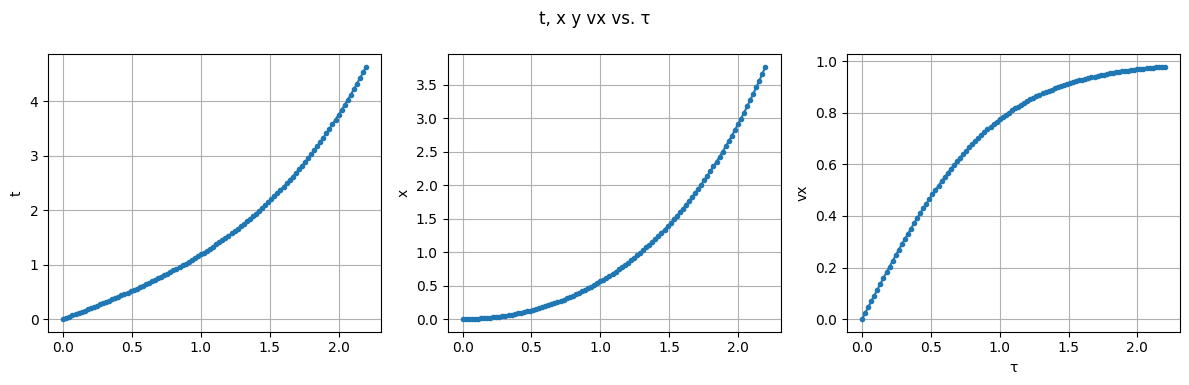

In [38]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

axs[0].plot(taus, ts, '-o', markersize=3)
axs[0].set_ylabel('t')
axs[0].grid(True)
plt.close(fig)
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
axs[0].plot(taus, ts, '-o', markersize=3)
axs[0].set_ylabel('t')
axs[0].grid(True)
axs[1].plot(taus, xs, '-o', markersize=3)
axs[1].set_ylabel('x')
axs[1].grid(True)

axs[2].plot(taus, vxs, '-o', markersize=3)
axs[2].set_ylabel('vx')
axs[2].set_xlabel('τ')
axs[2].grid(True)

fig.suptitle('t, x y vx vs. τ', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()